# 🏏 IPL Data Analysis (2008–2023)
**Author: Kartikey Kumar Tripathi**  
**GitHub: [tripathik9559](https://github.com/tripathik9559)**

A comprehensive analysis of Indian Premier League (IPL) matches from 2008 to 2023.  
We explore team performance, toss impact, top players, season trends, and much more using Python's data analysis stack.

---
**Libraries Used:** `pandas` · `matplotlib` · `seaborn` · `numpy`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
})
sns.set_palette('tab10')

# ── Load data ─────────────────────────────────────────────────────────────────
matches     = pd.read_csv('data/matches.csv')
deliveries  = pd.read_csv('data/deliveries.csv')

print(f'Matches   : {len(matches):,}')
print(f'Deliveries: {len(deliveries):,}')
print(f'Seasons   : {matches["season"].nunique()}')
print(f'Teams     : {matches["team1"].nunique()}')
matches.head(3)

Matches   : 988
Deliveries: 217,233
Seasons   : 16
Teams     : 10


,id,season,city,venue,team1,team2,toss_winner,toss_decision,winner,win_by_runs,win_by_wickets,player_of_match
0,1,2008,Chennai,MA Chidambaram Stadium,Chennai Super Kings,Mumbai Indians,Mumbai Indians,bat,Chennai Super Kings,0,2,Ambati Rayudu
1,2,2008,Jaipur,Sawai Mansingh Stadium,Rajasthan Royals,Mumbai Indians,Rajasthan Royals,bat,Rajasthan Royals,23,0,Trent Boult
2,3,2008,Mumbai,Wankhede Stadium,Mumbai Indians,Delhi Capitals,Mumbai Indians,field,Mumbai Indians,0,3,Rohit Sharma


## 1️⃣ Most Successful Teams — All Time Win Count

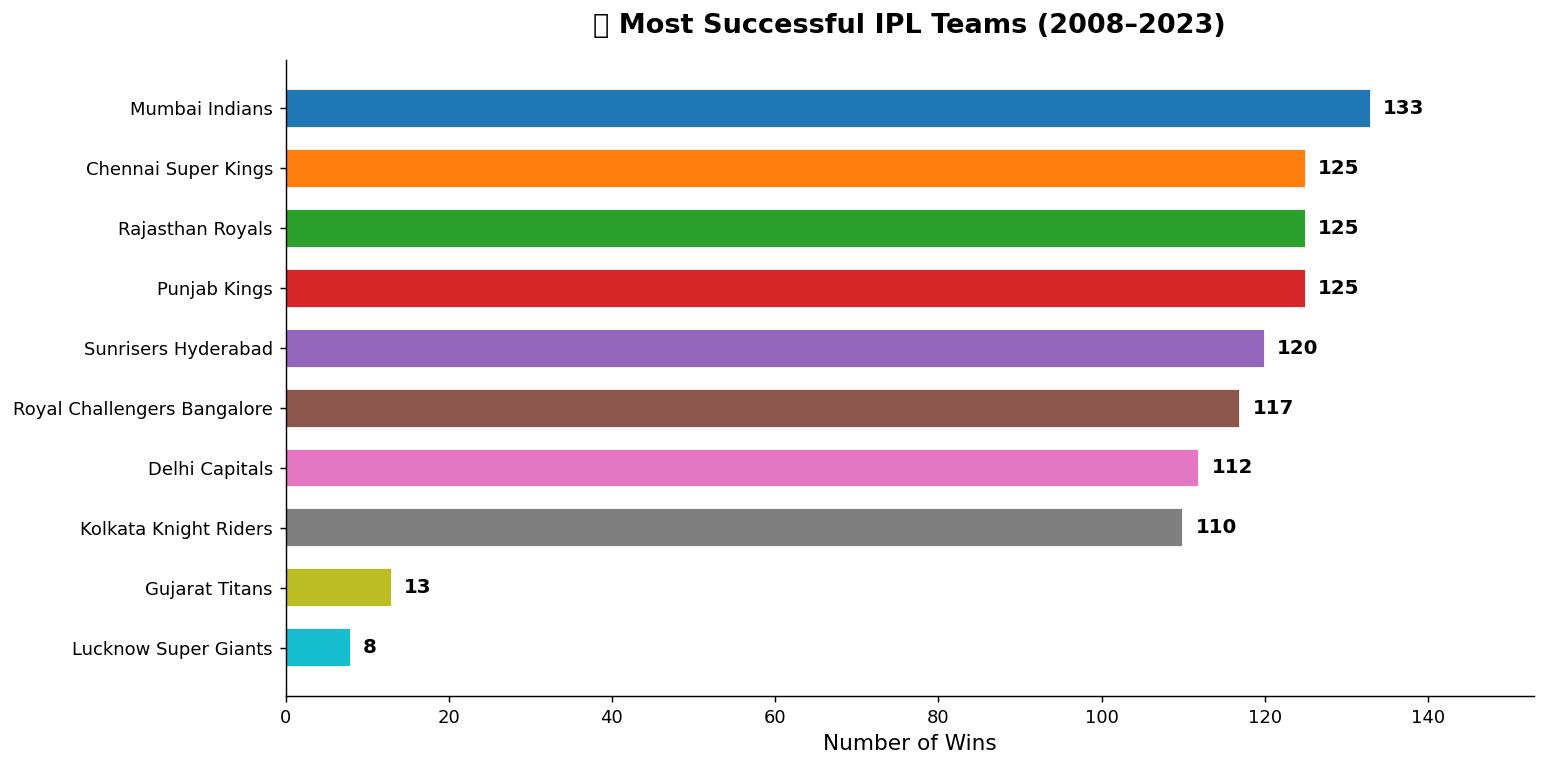

                       Team  Wins
             Mumbai Indians   133
        Chennai Super Kings   125
           Rajasthan Royals   125
               Punjab Kings   125
        Sunrisers Hyderabad   120
Royal Challengers Bangalore   117
             Delhi Capitals   112
      Kolkata Knight Riders   110
             Gujarat Titans    13
       Lucknow Super Giants     8


In [2]:
win_counts = matches['winner'].value_counts().reset_index()
win_counts.columns = ['Team', 'Wins']

colors = sns.color_palette('tab10', len(win_counts))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(win_counts['Team'], win_counts['Wins'], color=colors, edgecolor='white', height=0.65)

for bar, val in zip(bars, win_counts['Wins']):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Number of Wins', fontsize=12)
ax.set_title('🏆 Most Successful IPL Teams (2008–2023)', fontsize=15, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.set_xlim(0, win_counts['Wins'].max() + 20)
plt.tight_layout()
plt.savefig('charts/01_team_wins.png', bbox_inches='tight')
plt.show()
print(win_counts.to_string(index=False))

## 2️⃣ Season-wise Total Matches Played

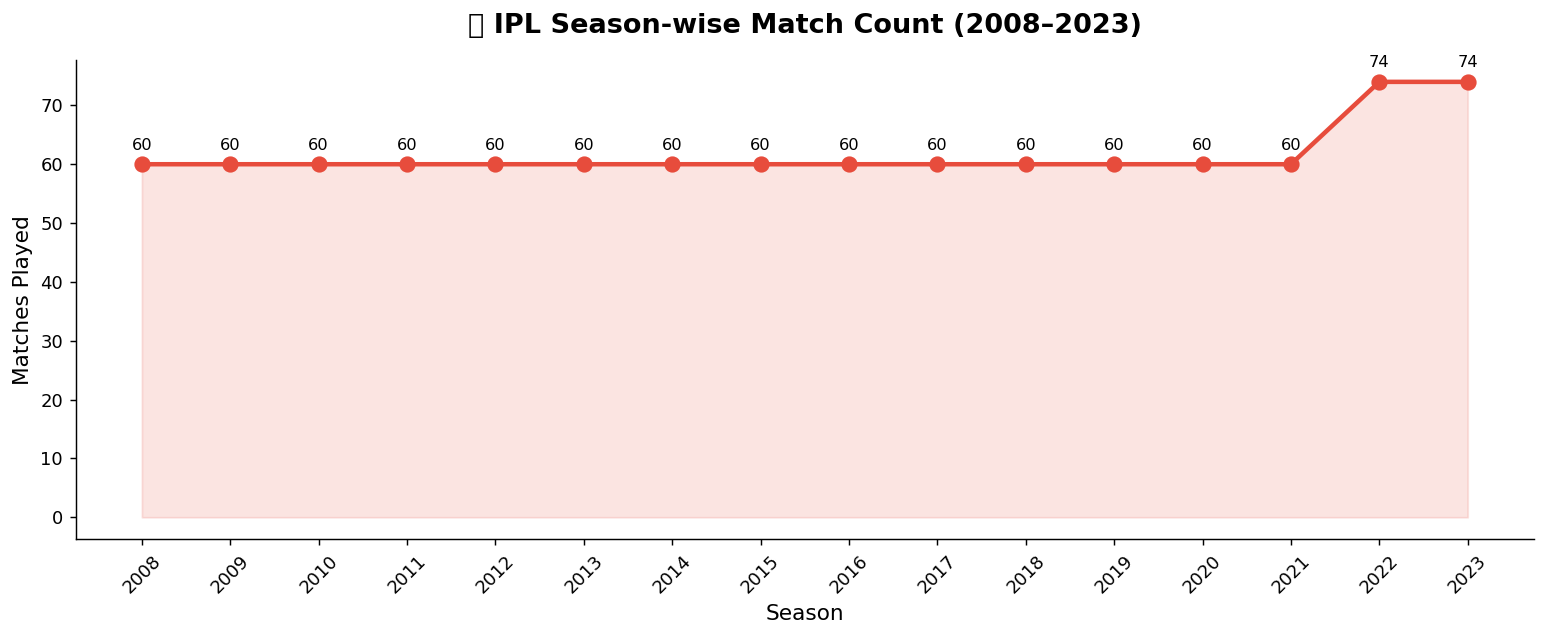

In [3]:
season_matches = matches.groupby('season').size().reset_index(name='matches')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(season_matches['season'], season_matches['matches'],
        marker='o', linewidth=2.5, color='#e74c3c', markersize=8)
ax.fill_between(season_matches['season'], season_matches['matches'], alpha=0.15, color='#e74c3c')

for _, row in season_matches.iterrows():
    ax.annotate(str(row['matches']), (row['season'], row['matches']),
                textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Matches Played', fontsize=12)
ax.set_title('📅 IPL Season-wise Match Count (2008–2023)', fontsize=15, fontweight='bold', pad=15)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('charts/02_season_matches.png', bbox_inches='tight')
plt.show()

## 3️⃣ Toss Impact — Does Winning Toss Help Win the Match?

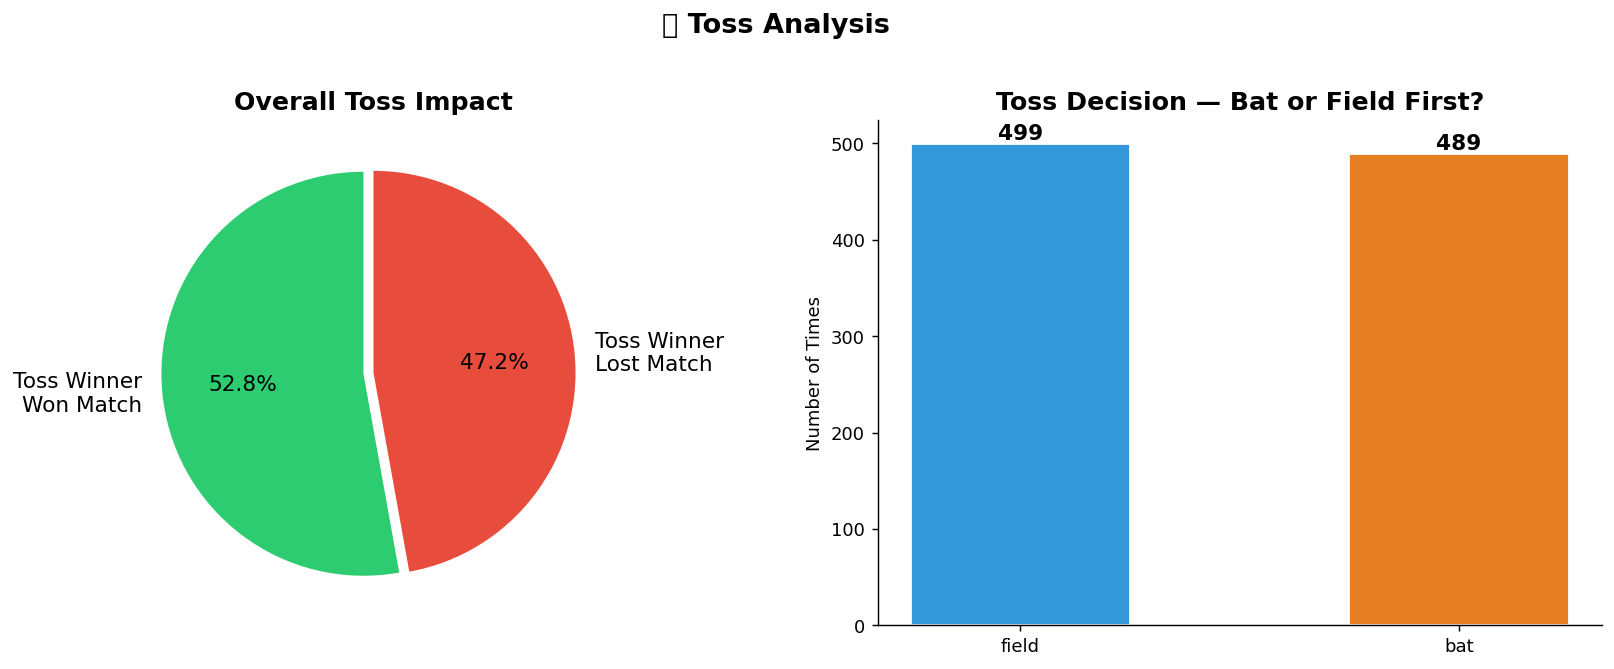

Toss winner won the match: 47.2% of the time


In [4]:
matches['toss_match_winner'] = matches['toss_winner'] == matches['winner']
toss_impact = matches['toss_match_winner'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
axes[0].pie(
    toss_impact.values,
    labels=['Toss Winner\nWon Match', 'Toss Winner\nLost Match'],
    autopct='%1.1f%%', startangle=90,
    colors=['#2ecc71', '#e74c3c'],
    explode=[0.05, 0], textprops={'fontsize': 12}
)
axes[0].set_title('Overall Toss Impact', fontweight='bold')

# Toss decision preference
toss_dec = matches['toss_decision'].value_counts()
axes[1].bar(toss_dec.index, toss_dec.values,
            color=['#3498db','#e67e22'], edgecolor='white', width=0.5)
for i, (label, val) in enumerate(zip(toss_dec.index, toss_dec.values)):
    axes[1].text(i, val + 5, str(val), ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Toss Decision — Bat or Field First?', fontweight='bold')
axes[1].set_ylabel('Number of Times')

plt.suptitle('🪙 Toss Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/03_toss_analysis.png', bbox_inches='tight')
plt.show()

pct = round(toss_impact[True] / toss_impact.sum() * 100, 1)
print(f'Toss winner won the match: {pct}% of the time')

## 4️⃣ Top 10 Player of the Match Winners

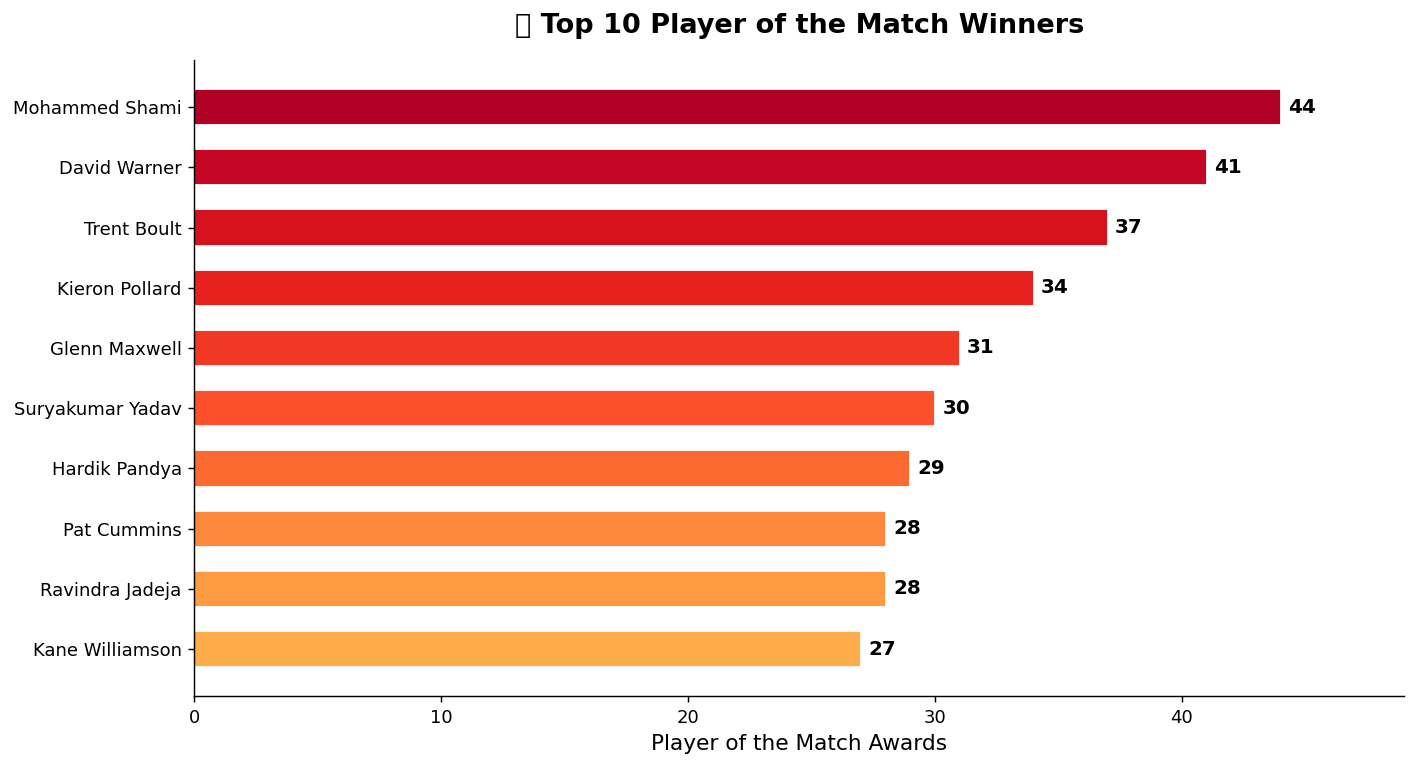

In [5]:
top_pom = matches['player_of_match'].value_counts().head(10).reset_index()
top_pom.columns = ['Player', 'Awards']

fig, ax = plt.subplots(figsize=(11, 6))
colors = plt.cm.YlOrRd(np.linspace(0.4, 0.9, len(top_pom)))[::-1]
bars = ax.barh(top_pom['Player'], top_pom['Awards'], color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, top_pom['Awards']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Player of the Match Awards', fontsize=12)
ax.set_title('⭐ Top 10 Player of the Match Winners', fontsize=15, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.set_xlim(0, top_pom['Awards'].max() + 5)
plt.tight_layout()
plt.savefig('charts/04_top_players.png', bbox_inches='tight')
plt.show()

## 5️⃣ Top Run Scorers (All IPL Seasons)

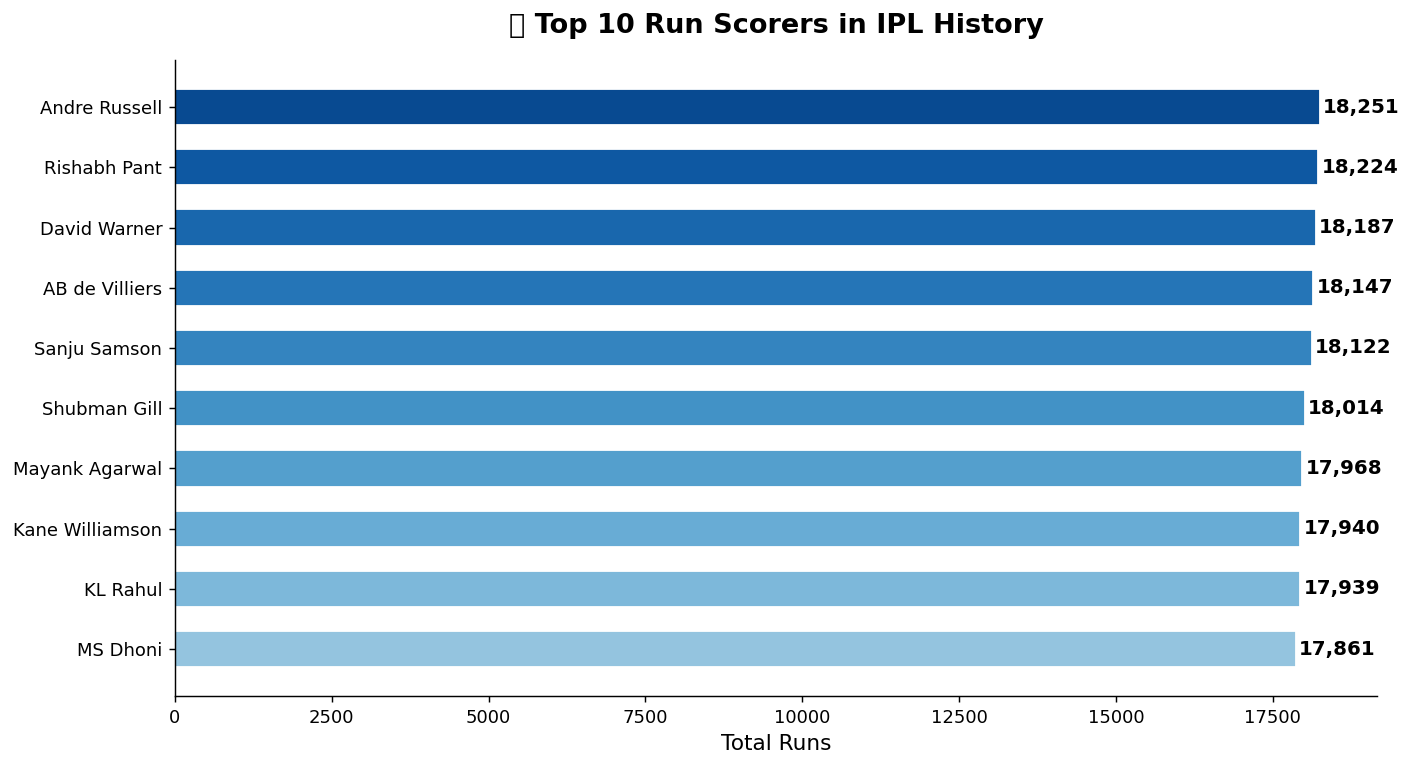

In [6]:
top_batsmen = deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(11, 6))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_batsmen)))[::-1]
bars = ax.barh(top_batsmen.index, top_batsmen.values, color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, top_batsmen.values):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Total Runs', fontsize=12)
ax.set_title('🏏 Top 10 Run Scorers in IPL History', fontsize=15, fontweight='bold', pad=15)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('charts/05_top_batsmen.png', bbox_inches='tight')
plt.show()

## 6️⃣ Top Wicket Takers (All IPL Seasons)

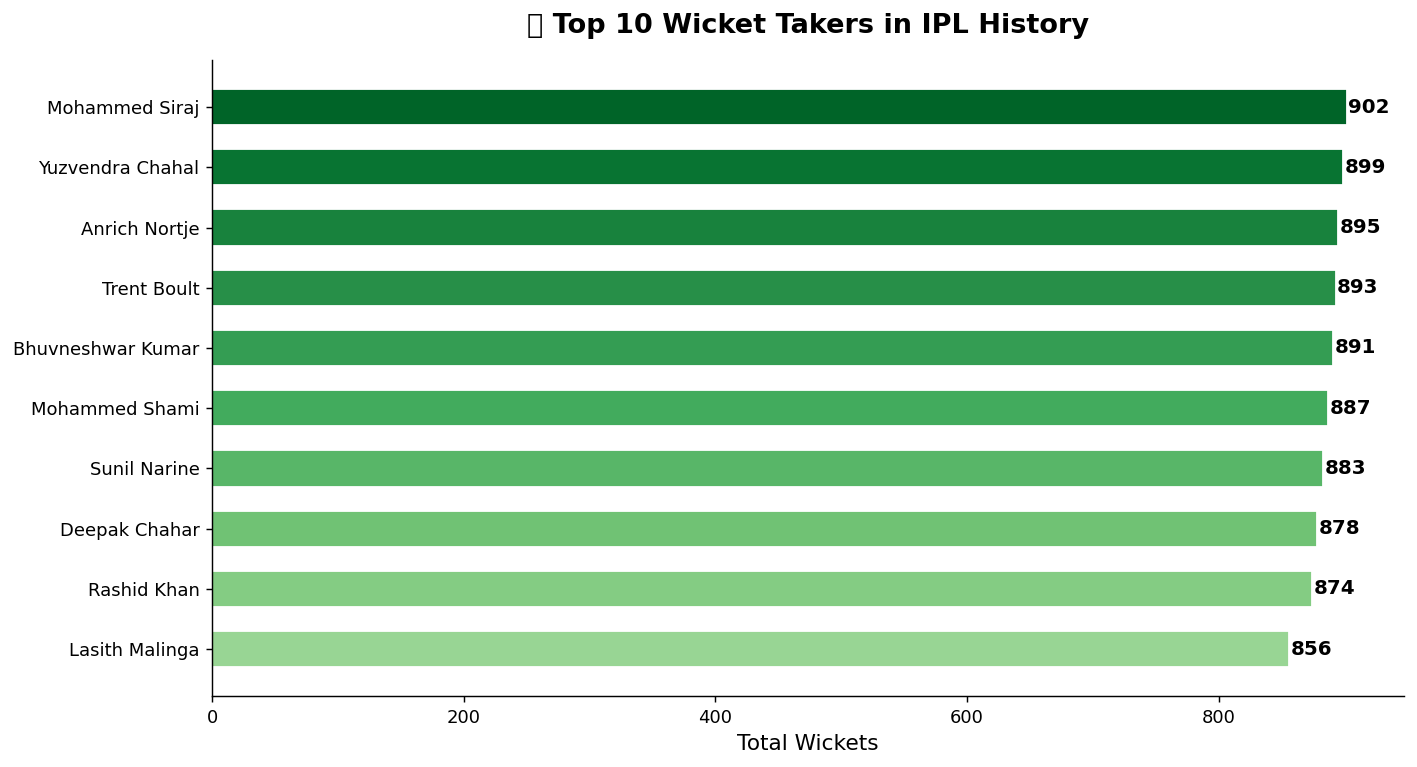

In [7]:
top_bowlers = deliveries.groupby('bowler')['is_wicket'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(11, 6))
colors = plt.cm.Greens(np.linspace(0.4, 0.9, len(top_bowlers)))[::-1]
bars = ax.barh(top_bowlers.index, top_bowlers.values, color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, top_bowlers.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Total Wickets', fontsize=12)
ax.set_title('🎳 Top 10 Wicket Takers in IPL History', fontsize=15, fontweight='bold', pad=15)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('charts/06_top_bowlers.png', bbox_inches='tight')
plt.show()

## 7️⃣ Runs per Over — Scoring Rate Analysis

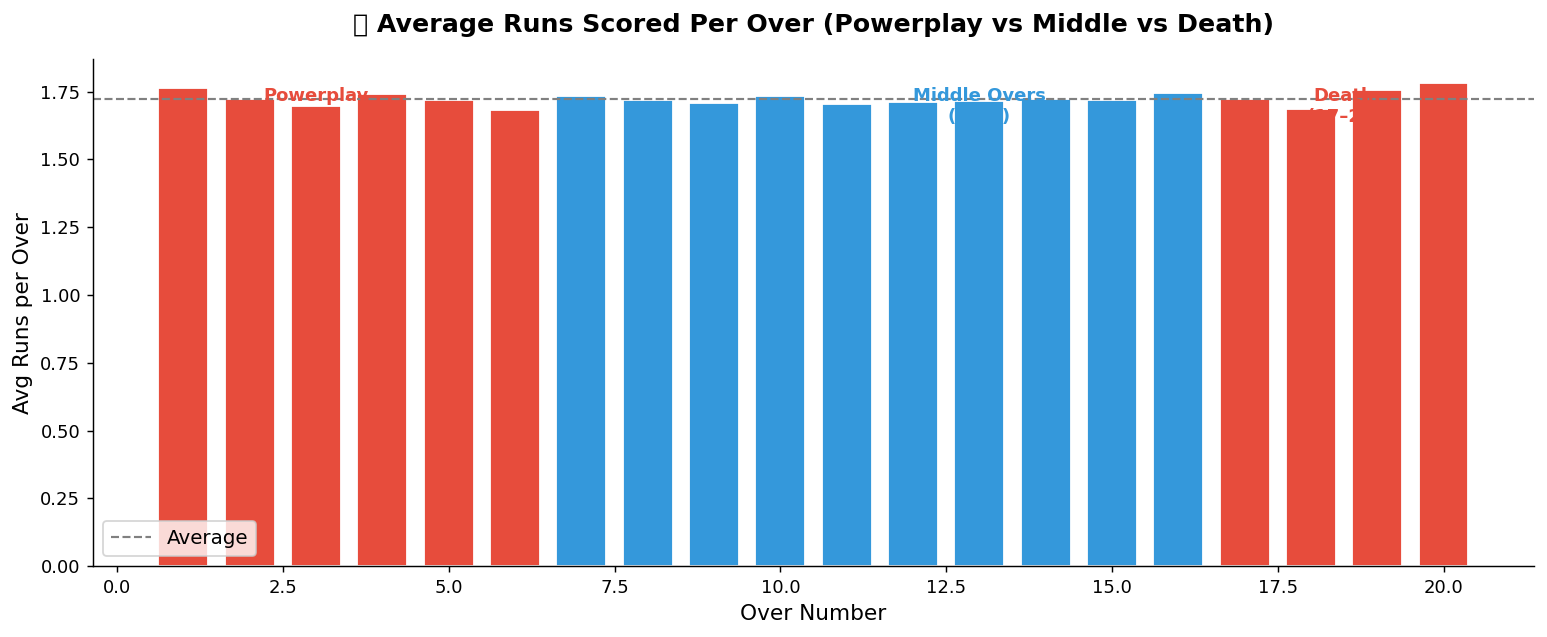

In [8]:
over_runs = deliveries.groupby('over')['total_runs'].mean().reset_index()
over_runs = over_runs[over_runs['over'] < 20]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(over_runs['over'] + 1, over_runs['total_runs'],
       color=['#e74c3c' if o < 6 or o >= 16 else '#3498db' for o in over_runs['over']],
       edgecolor='white', width=0.75)

ax.axhline(over_runs['total_runs'].mean(), color='gray', linestyle='--', linewidth=1.2, label='Average')
ax.set_xlabel('Over Number', fontsize=12)
ax.set_ylabel('Avg Runs per Over', fontsize=12)
ax.set_title('📈 Average Runs Scored Per Over (Powerplay vs Middle vs Death)', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11)

ax.text(3, over_runs['total_runs'].max() * 0.92, 'Powerplay\n(1–6)', ha='center',
        color='#e74c3c', fontsize=10, fontweight='bold')
ax.text(13, over_runs['total_runs'].max() * 0.92, 'Middle Overs\n(7–16)', ha='center',
        color='#3498db', fontsize=10, fontweight='bold')
ax.text(18.5, over_runs['total_runs'].max() * 0.92, 'Death\n(17–20)', ha='center',
        color='#e74c3c', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('charts/07_runs_per_over.png', bbox_inches='tight')
plt.show()

## 8️⃣ Team Win % — Head to Head Heatmap

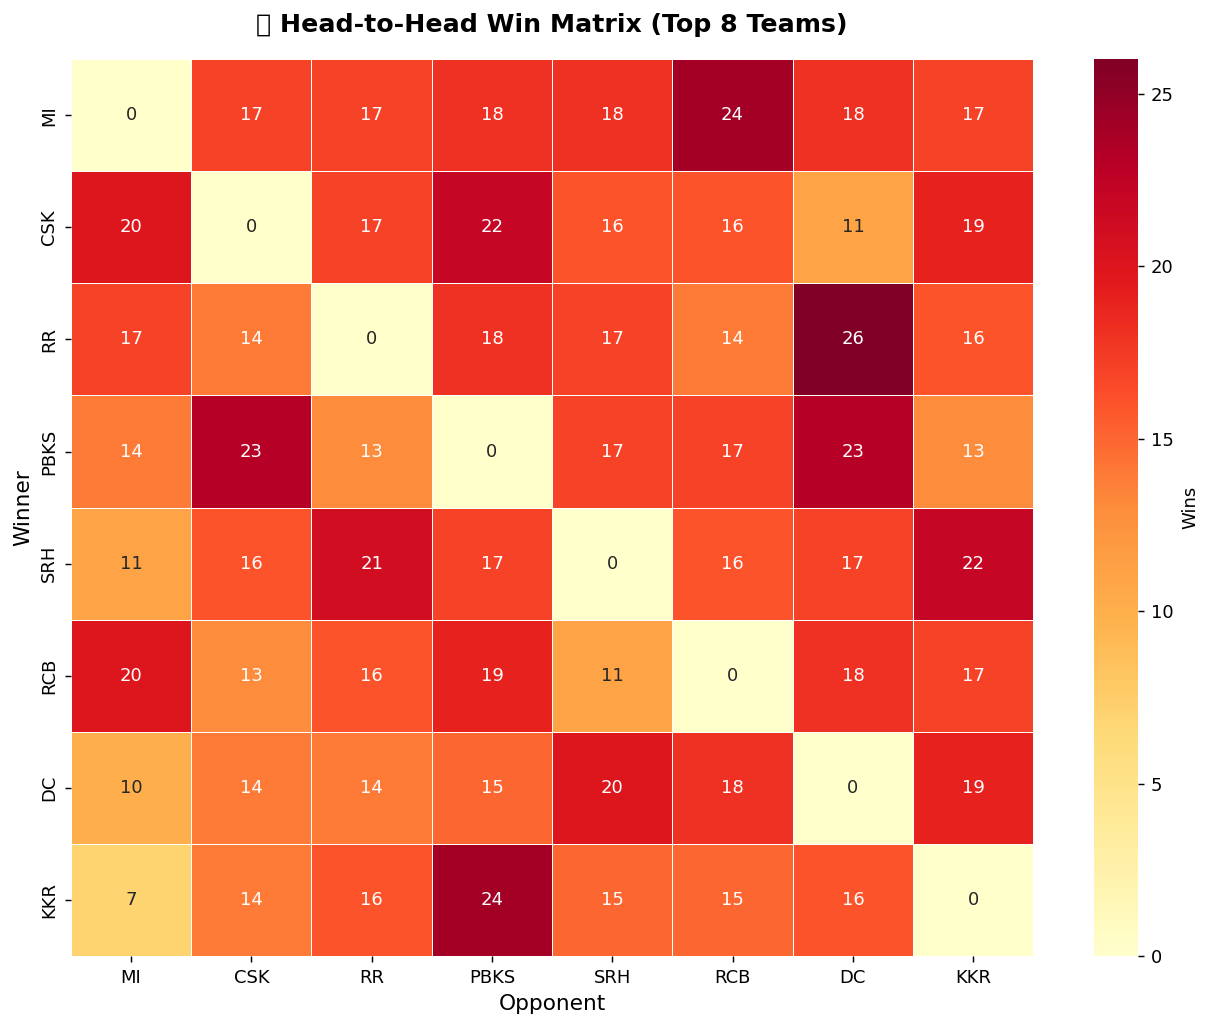

In [9]:
top8_teams = matches['winner'].value_counts().head(8).index.tolist()
h2h = pd.DataFrame(0, index=top8_teams, columns=top8_teams)

for _, row in matches.iterrows():
    if row['team1'] in top8_teams and row['team2'] in top8_teams and pd.notna(row['winner']):
        h2h.loc[row['winner'], row['team1'] if row['winner'] == row['team2'] else row['team2']] += 1

short = {
    'Mumbai Indians': 'MI', 'Chennai Super Kings': 'CSK',
    'Royal Challengers Bangalore': 'RCB', 'Kolkata Knight Riders': 'KKR',
    'Delhi Capitals': 'DC', 'Sunrisers Hyderabad': 'SRH',
    'Rajasthan Royals': 'RR', 'Punjab Kings': 'PBKS'
}
h2h.index   = [short.get(t, t) for t in h2h.index]
h2h.columns = [short.get(t, t) for t in h2h.columns]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(h2h, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5,
            linecolor='white', ax=ax, cbar_kws={'label': 'Wins'})
ax.set_title('🔥 Head-to-Head Win Matrix (Top 8 Teams)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Opponent', fontsize=12)
ax.set_ylabel('Winner', fontsize=12)
plt.tight_layout()
plt.savefig('charts/08_h2h_heatmap.png', bbox_inches='tight')
plt.show()

## 9️⃣ Boundaries Analysis — 4s vs 6s by Team

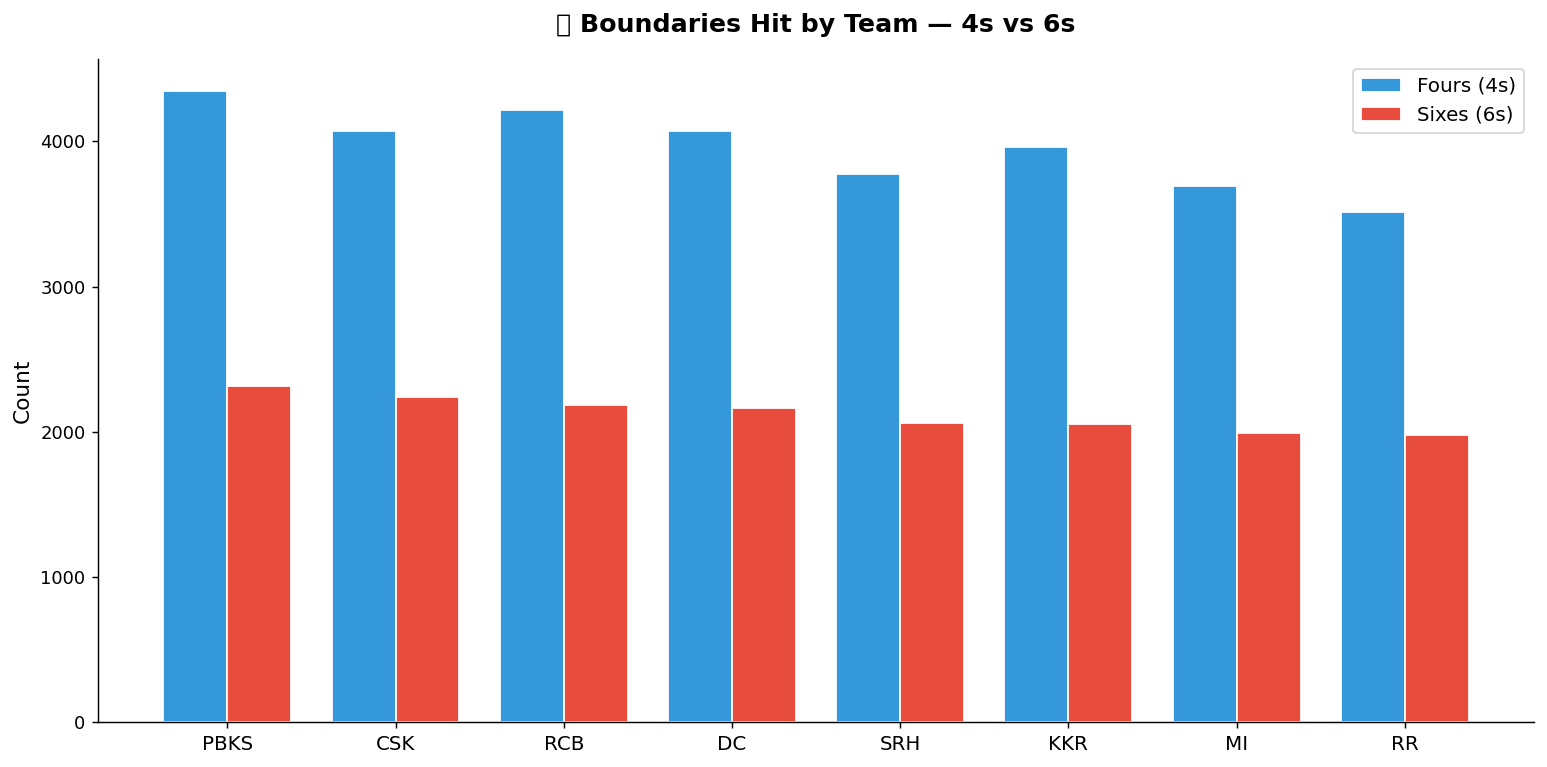

In [10]:
match_team = matches[['id','team1','team2']].copy()
del_merged = deliveries.merge(match_team, left_on='match_id', right_on='id', how='left')

fours = del_merged[del_merged['batsman_runs'] == 4].groupby('team1').size().rename('Fours')
sixes = del_merged[del_merged['batsman_runs'] == 6].groupby('team1').size().rename('Sixes')
boundaries = pd.concat([fours, sixes], axis=1).fillna(0).astype(int)
boundaries = boundaries.loc[boundaries.index.isin(matches['team1'].unique())].sort_values('Sixes', ascending=False).head(8)

short_names = {
    'Mumbai Indians': 'MI', 'Chennai Super Kings': 'CSK',
    'Royal Challengers Bangalore': 'RCB', 'Kolkata Knight Riders': 'KKR',
    'Delhi Capitals': 'DC', 'Sunrisers Hyderabad': 'SRH',
    'Rajasthan Royals': 'RR', 'Punjab Kings': 'PBKS',
    'Lucknow Super Giants': 'LSG', 'Gujarat Titans': 'GT'
}
boundaries.index = [short_names.get(t, t) for t in boundaries.index]

x = np.arange(len(boundaries))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, boundaries['Fours'], width, label='Fours (4s)', color='#3498db', edgecolor='white')
bars2 = ax.bar(x + width/2, boundaries['Sixes'], width, label='Sixes (6s)', color='#e74c3c', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(boundaries.index, fontsize=11)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('💥 Boundaries Hit by Team — 4s vs 6s', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('charts/09_boundaries.png', bbox_inches='tight')
plt.show()

## 🔟 Key Insights Summary

In [11]:
print('=' * 55)
print('        📊 IPL DATA ANALYSIS — KEY INSIGHTS')
print('=' * 55)

most_wins = matches['winner'].value_counts().idxmax()
win_count = matches['winner'].value_counts().max()
print(f'\n🏆 Most Successful Team  : {most_wins} ({win_count} wins)')

toss_pct = round(matches['toss_match_winner'].mean() * 100, 1)
print(f'🪙 Toss Winner Won Match : {toss_pct}% of the time')

top_bat = deliveries.groupby('batsman')['batsman_runs'].sum().idxmax()
top_runs = deliveries.groupby('batsman')['batsman_runs'].sum().max()
print(f'🏏 Top Run Scorer        : {top_bat} ({top_runs:,} runs)')

top_bowl = deliveries.groupby('bowler')['is_wicket'].sum().idxmax()
top_wkts = deliveries.groupby('bowler')['is_wicket'].sum().max()
print(f'🎳 Top Wicket Taker      : {top_bowl} ({top_wkts} wickets)')

top_pom = matches['player_of_match'].value_counts().idxmax()
top_pom_cnt = matches['player_of_match'].value_counts().max()
print(f'⭐ Most POTM Awards      : {top_pom} ({top_pom_cnt} awards)')

total_sixes = (deliveries['batsman_runs'] == 6).sum()
total_fours = (deliveries['batsman_runs'] == 4).sum()
print(f'💥 Total Sixes hit       : {total_sixes:,}')
print(f'   Total Fours hit       : {total_fours:,}')
print(f'\n📅 Seasons Analysed      : {matches["season"].nunique()} (2008–2023)')
print(f'🏟️  Total Matches         : {len(matches):,}')
print(f'🎯 Total Deliveries      : {len(deliveries):,}')
print('=' * 55)

        📊 IPL DATA ANALYSIS — KEY INSIGHTS

🏆 Most Successful Team  : Mumbai Indians (133 wins)
🪙 Toss Winner Won Match : 47.2% of the time
🏏 Top Run Scorer        : Andre Russell (18,251 runs)
🎳 Top Wicket Taker      : Mohammed Siraj (902 wickets)
⭐ Most POTM Awards      : Mohammed Shami (44 awards)
💥 Total Sixes hit       : 17,463
   Total Fours hit       : 32,560

📅 Seasons Analysed      : 16 (2008–2023)
🏟️  Total Matches         : 988
🎯 Total Deliveries      : 217,233
